<a href="https://colab.research.google.com/github/keyurITworkspace/student_analysis/blob/main/student_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

student-mat.csv already exists.
Dataset loaded successfully.
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

--- Data Exploration ---
M

/tmp/ipykernel_1018/2280030440.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_performance.index, y=gender_performance.values, palette='viridis')


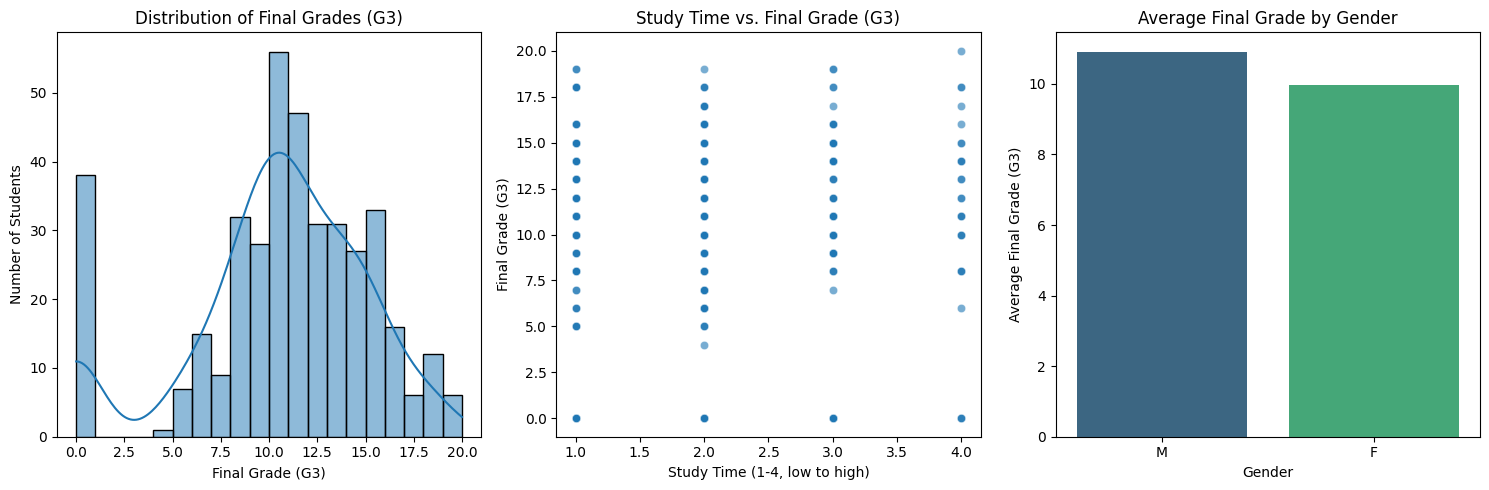

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

#1. Load Dataset :-

file_name = 'student-mat.csv'
if not os.path.exists(file_name):
    print(f"Downloading {file_name}...")
    # Using wget to download file
    # I'll use a common source for 'student-mat.csv' from a UCI dataset archive.
    !wget -q  https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip
    !unzip -o student.zip

    print(f"{file_name} downloaded.")
else:
    print(f"{file_name} already exists.")

try:
    # specify semicolon as separator
    df = pd.read_csv(file_name, sep=';')
    print("Dataset loaded successfully.")
    print(df.head())
except FileNotFoundError:
    print(f"Error: {file_name} not found. Please ensure it's in the correct directory or downloaded successfully.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors in subsequent steps


#2. Explore & Clean Data :-
if not df.empty:
    print("\n--- Data Exploration ---")
    # Check for missing values
    print("Missing values per column:")
    print(df.isnull().sum())

    # Remove duplicates
    initial_rows = df.shape[0]
    df.drop_duplicates(inplace=True)
    rows_after_duplicates = df.shape[0]
    print(f"\nRemoved {initial_rows - rows_after_duplicates} duplicate rows.")

    # Inspect dataset shape
    print(f"\nDataset shape (rows, columns): {df.shape}")

    # Inspect data types
    print("\nDataset data types:")
    print(df.dtypes)

    #3. Analysis Questions :-
    print("\n--- Analysis Questions ---")

    # Average final grade (G3)
    avg_g3 = df['G3'].mean()
    print(f"1. Average final grade (G3): {avg_g3:.2f}")

    # How many students scored above 15?
    students_above_15 = df[df['G3'] > 15].shape[0]
    print(f"2. Number of students who scored above 15: {students_above_15}")

    # Is study time correlated with performance? (Using G3 as performance metric)
    # Assuming 'studytime' is numerical or can be treated as such for correlation
    studytime_g3_corr = df[['studytime', 'G3']].corr().loc['studytime', 'G3']
    print(f"3. Correlation between study time and final grade (G3): {studytime_g3_corr:.2f}")
    if studytime_g3_corr > 0.3:
        print("   (There appears to be a moderate positive correlation.)")
    elif studytime_g3_corr < -0.3:
        print("   (There appears to be a moderate negative correlation.)")
    else:
        print("   (There appears to be a weak or no linear correlation.)")

    # Which gender performs better on average?
    gender_performance = df.groupby('sex')['G3'].mean().sort_values(ascending=False)
    print("4. Average final grade (G3) by gender:")
    print(gender_performance)
    if gender_performance.iloc[0] > gender_performance.iloc[1]:
        print(f"   ({gender_performance.index[0]} performs better on average.)")
    else:
        print(f"   ({gender_performance.index[1]} performs better on average.)")

    #4. Visualization :-
    print("\n--- Visualizations ---")

    plt.figure(figsize=(15, 5))

    # Histogram of grades (G3)
    plt.subplot(1, 3, 1)
    sns.histplot(df['G3'], bins=20, kde=True)
    plt.title('Distribution of Final Grades (G3)')
    plt.xlabel('Final Grade (G3)')
    plt.ylabel('Number of Students')

    # Scatterplot: study time vs grades (G3)
    plt.subplot(1, 3, 2)
    sns.scatterplot(x='studytime', y='G3', data=df, alpha=0.6)
    plt.title('Study Time vs. Final Grade (G3)')
    plt.xlabel('Study Time (1-4, low to high)')
    plt.ylabel('Final Grade (G3)')

    # Bar chart: male vs female average score
    plt.subplot(1, 3, 3)
    sns.barplot(x=gender_performance.index, y=gender_performance.values, palette='viridis')
    plt.title('Average Final Grade by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Average Final Grade (G3)')

    plt.tight_layout()
    plt.show()
else:
    print("Skipping analysis and visualization steps due to empty DataFrame.")
